In [1]:
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.cluster import KMeans

In [2]:
image = Image.open('image.jpg')

print("Original size:", image.size)

Original size: (1050, 667)


In [3]:
image = image.resize((396, 396))

print("New size:", image.size)

New size: (396, 396)


In [4]:
image = image.convert('RGB')

image_array = np.array(image)

print("Image shape:", image_array.shape)

Image shape: (396, 396, 3)


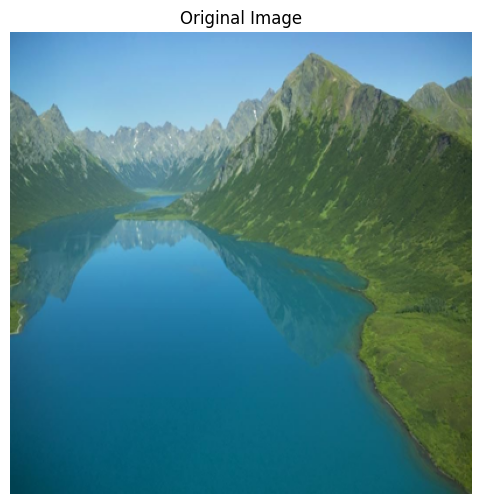

In [5]:
plt.figure(figsize=(6, 6))

plt.imshow(image_array)
plt.axis('off')
plt.title('Original Image')

plt.show()

In [6]:
pixels = image_array.reshape(-1, 3)

print("Pixel data shape:", pixels.shape)

Pixel data shape: (156816, 3)


In [7]:
model = KMeans(
    n_clusters=16,
    random_state=42,
    n_init=10
)

In [8]:
model.fit(pixels)

print("K-Means training completed.")

K-Means training completed.


In [9]:
labels = model.labels_

print("Labels shape:", labels.shape)

Labels shape: (156816,)


In [10]:
colors = model.cluster_centers_

print("Number of colors:", len(colors))
print(colors)

Number of colors: 16
[[  8.12308774  83.52171619 104.21927202]
 [145.18735798 196.72815534 227.24323487]
 [ 94.43272116 121.24594887 104.18377146]
 [ 43.89133285 130.68608886 173.89643117]
 [ 58.8186747   79.28975904  51.02383821]
 [120.64614757 142.08336731 125.15960049]
 [ 10.14166826 100.21675935 125.35704698]
 [117.08885827 175.2746685  220.76407784]
 [ 92.19076565 115.97814278  62.36717538]
 [ 95.07350296 143.31611411 154.44307376]
 [ 74.80613968  96.42939371  52.5676132 ]
 [ 24.35172311 110.10166704 145.90184645]
 [ 45.52535125 109.49629112 119.91927742]
 [142.5888522  169.1759565  170.61565352]
 [ 81.01511508 155.72844383 200.14771556]
 [ 69.40592605 100.54137871  81.78593642]]


In [11]:
compressed_pixels = colors[labels]

compressed_image = compressed_pixels.reshape(396, 396, 3)

compressed_image = np.clip(
    compressed_image,
    0,
    255
).astype(np.uint8)

print("Compressed image shape:", compressed_image.shape)

Compressed image shape: (396, 396, 3)


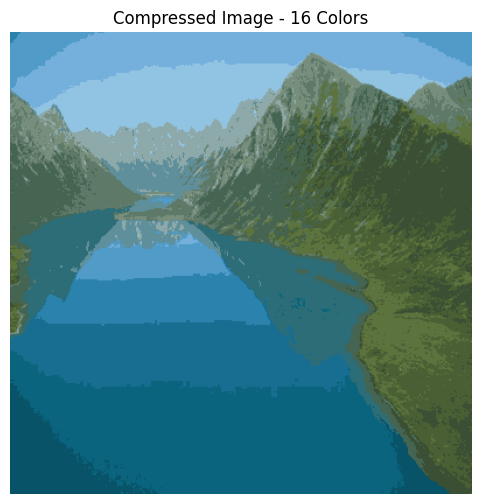

In [12]:
plt.figure(figsize=(6, 6))

plt.imshow(compressed_image)
plt.axis('off')
plt.title('Compressed Image - 16 Colors')

plt.show()

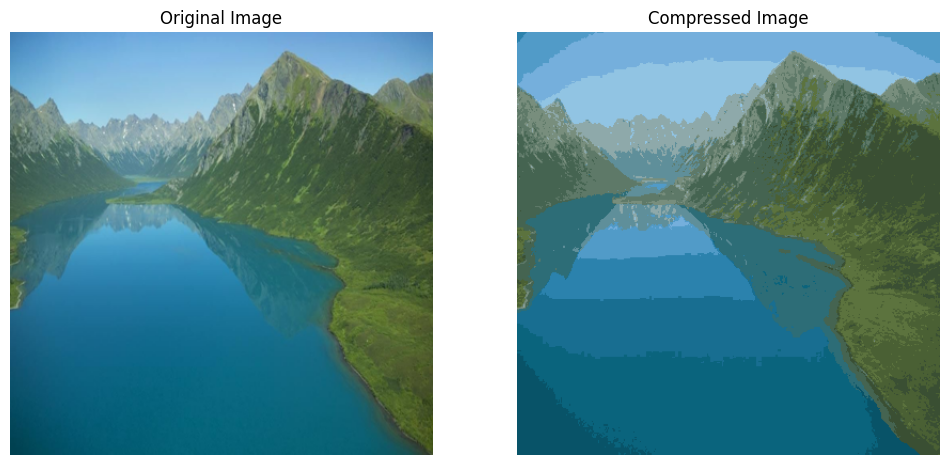

In [13]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(image_array)
plt.axis('off')
plt.title('Original Image')

plt.subplot(1, 2, 2)
plt.imshow(compressed_image)
plt.axis('off')
plt.title('Compressed Image')

plt.show()

In [14]:
compressed_image_pil = Image.fromarray(compressed_image)

compressed_image_pil.save(
    'compressed_image.jpg'
)

print("Compressed image saved successfully.")

Compressed image saved successfully.
